In [1]:
#imported from Pranav Sanghavi's notebook 
import glob 
import os 
import time
import h5py
import matplotlib.pylab as plt
import numpy as np
import numpy.ma as ma
from matplotlib.offsetbox import AnchoredText
from matplotlib.pylab import colorbar 
from skrf import Network, Frequency
from platform import python_version
import math
import psutil
import matplotlib.cm as cm
from scipy.stats import iqr
import pytz,pickle,yaml,sys
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
#importing for Will's extract_source_pulses function 
from scipy import interpolate
import datetime
from scipy.signal import square
from scipy.stats import pearsonr
import pandas
import time_utils as tu
from mpl_toolkits.axes_grid1 import make_axes_locatable
#importing for drone and corr data synchronization
import pandas as pd
import datetime
import h5py
import os
import pygeodesy

#import the beamcals module, use forked repository (not original):
#sys.path.insert(0, '../../classes/')
#import corr, concat, drone
#import plotting_utils as pu
#import fitting_utils as fu
#import geometry_utils as gu
import time_utils as tu
#import site_utils as si
#gbosite=si.Site('../../metadata/TONE_d5_config.npz')
#gbosite=si.Site('/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/GBO_acq/TONE_d5_config.npz')

np.set_printoptions(threshold=np.inf)

style = 'fast'
tick_dir = 'in'
plt.style.use(style)
plt.rcParams['xtick.direction'] = tick_dir
plt.rcParams['ytick.direction'] = tick_dir
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['font.size'] = 15
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"})

###################################################################################
# Analog chain labels
###################################################################################

#pathtoacfile = "/home/observer/tone_jupyter/anachainz.csv"
#ac = np.genfromtxt(pathtoacfile, delimiter=",", names=True,
#                   dtype=(int, int, 'U5', 'U5', int, 'U2', int))
#inputs = ac['feed']

def get_beam_fwhm(d=6.0, nu=600):
    fwhm = constants.c/(nu*1e6)/d   # lambda/D
    return np.rad2deg(fwhm * 1.22)

def gaussian(x, a, mean, sigma):
    val = a * np.exp(-(x - mean)**2 / sigma**2)
    return val

def scale_zero_one(x):
    return (x - x.min())/(x.max() - x.min())

def seconds_to_degrees(seconds, declination=22.0145):
    """
        This function converts seconds to degrees of sky motion at a latitude 
        default TONE latitude -- default for crab.
    """
    return seconds * np.cos(np.deg2rad(declination)) / 240

def read_corr_mode_h5(file_path, f_start=None, f_stop=None):
    """
        This function reads all hdf5 files.
    """
    class correlator_data:
        def __init__(self, vis, time, sat, index_map):
            self.vis = vis
            self.time = time
            self.sat = sat
            self.freq = index_map["freq"][:]
            self.prod = index_map['prod'][:]
    files = glob.glob(file_path + "*[!.lock]")
    files.sort()
    
    #grab different sets of files.  
    if f_start is not None:
        if f_stop is not None:
            files = files[f_start:f_stop]
        else:
            files = files[f_start:]
    if f_start is None:
        if f_stop is not None:
            files = files[:f_stop]

    try:
        t = 0
        for x in files:
            print(f"Reading File: {x}")
            f = h5py.File(x, "r")
            index_map = f['index_map']
            if(t == 0):
                vis = f['vis'][:]
                time = index_map['time'][:]
                sat = f['sat'][:]
                print("Appended vis data and time stream from %s" % (x))
                t = t + 1
            else:
                time = np.append(time, index_map['time'][:])
                vis = np.append(vis, f['vis'][:], axis=0)
                sat = np.append(sat, f['sat'][:], axis=0)
                print("Appended vis data and time stream from %s" % (x))
        
        return correlator_data(
            vis,
            time,
            sat,
            index_map
        )
    finally:
        print("Done!!!!!!!")

def get_mag_phase(corr_dat):
    """
        This function returns magnitude and phase in degrees of correlations.
    """
    return np.absolute(corr_dat), np.rad2deg(np.angle(corr_dat))

def plot_waterfall_corr_data(data, corr_indices):
    """
        This function plots waterfall across 1024 frequency channels.
        Frequency range: 400-800MHz
    """
    fig=plt.figure(figsize=(20,20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for i,auto in enumerate(corr_indices):
        ax=plt.subplot(dim1, dim2, i + 1)
        wfall = data[:, :, auto] # auto -> corr index 
        im=plt.imshow(wfall, vmin = np.nanpercentile(wfall,5), vmax =np.nanpercentile(wfall,95), cmap='gnuplot2', aspect='auto')
        plt.xlabel("freq index")
        plt.ylabel("time index")
        plt.title(f"corr {corr_data.prod[auto]}")
        divider=make_axes_locatable(ax)
        cax=divider.append_axes("right", size="5%", pad=0.05)
        cbar=fig.colorbar(im,cax=cax)
        cbar.set_label('Power [$ADU^2$]')
    plt.tight_layout()
    
def plot_freq_channel_corr_data(pow_mag, freq_index, freq, corr_indices):
    """
        This function plots phase for a given frequency index for given time window.
    """
    plt.figure(figsize=(20, 20))
    dim1 = math.floor(math.sqrt(len(corr_indices)))
    dim2 = math.ceil(len(corr_indices)/dim1)
    for index, corr_index in enumerate(corr_indices):
            plt.subplot(dim1, dim2, index + 1)
            plt.title(f"Corr: {corr_data.prod[corr_index]}")
            plt.plot(pow_mag[:, freq_index, corr_index])
    plt.suptitle(f"Frequency {freq} MHz")
    plt.tight_layout()
    
def plot_phase_corr_data(pow_phase, corr_indices, t_ind_arr):
    """
        This function plots phase for a given time index across frequency range of 400-800MHz.
    """
    for i, t_index in enumerate(t_ind_arr):
        fig= plt.figure(figsize=(25, 10))
        dim1 = math.floor(math.sqrt(len(corr_indices)*len(t_ind_arr)))
        dim2 = math.ceil(len(corr_indices)*len(t_ind_arr)/dim1)
        for index, corr_index in enumerate(corr_indices):
                ax = plt.subplot(dim2, dim1, i + 1)
                ax.plot(pow_phase[t_index,:, corr_index], c=colorsarr[300], label=f'time index {t_index}')
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                plt.xlabel(f"frequency index")
                plt.ylabel(f"phase (degrees)")
                plt.title(f"Corr: {corr_data.prod[corr_index]}")
                #plt.suptitle(f"Correlated noise phase")
        plt.tight_layout()
        
def chunk_lists_(data_):
    """
        This function makes sublists of time indices of individual ON/OFF pulses.
        Returns list of lists
    """
    consecutive_list = []

    for chunks in range(len(data_)):
        try:
            if data_[chunks + 1] - data_[chunks] == 1:
                #check if index is already in list:
                if data_[chunks] not in consecutive_list:
                    consecutive_list.append(data_[chunks])
                #add last index too
                consecutive_list.append(data_[chunks + 1])
            else:
                yield consecutive_list
                consecutive_list = []        
        except Exception:
            pass   
    yield consecutive_list
    
def split_into_small_lists(big_lists, small_size=4, long_threshold=11, n_chunks=3, min_len=2):
    """
        This function splits the sublists of time indices of individual ON/OFF pulses into 3/4-element lists
        Returns list of lists
        - ≤11 elements: chunk into small_size
        - ≤2 elements: throw away the list 
    """
    small_chunks = []
    for list1 in big_lists:
        if len(list1) <= long_threshold:
            small_groups = [list1[i:i + small_size] for i in range(0, len(list1), small_size)]
        small_chunks.extend(small_groups)
    return [group for group in small_chunks if len(group) >= min_len]  # Drop empties if any

def cm_to_discrete(base_cmap, N):
    base = plt.cm.get_cmap(base_cmap)   # or pass a colormap instance
    colors = base(np.linspace(0, 1, N))
    return ListedColormap(colors)

## reading the required only corr files for plotting beam pattern

In [2]:
## 5m/s double pass 

file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*'

# reading files for main beam pass
corr_data1 = read_corr_mode_h5(file_path, f_start=127, f_stop=129)
#corr_data1 = read_corr_mode_h5(file_path, f_start=99, f_stop=102) -- 2.5m/s
pow_mag1, pow_phase1 = get_mag_phase(corr_data1.vis)

file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*'

# reading files for main beam pass 
corr_data2 = read_corr_mode_h5(file_path, f_start=129, f_stop=132)
#corr_data2 = read_corr_mode_h5(file_path, f_start=101, f_stop=104) -- 2.5ms
pow_mag2, pow_phase2 = get_mag_phase(corr_data2.vis)

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0127
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0127
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0128
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0128
Done!!!!!!!
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0129
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_so

## If want to check against time samples ----

corr noise data shape: (512, 1024, 10)
Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 512
lowest time bin 0 and highest time bin 512
21.47483648 seconds of data (considered for the plots)


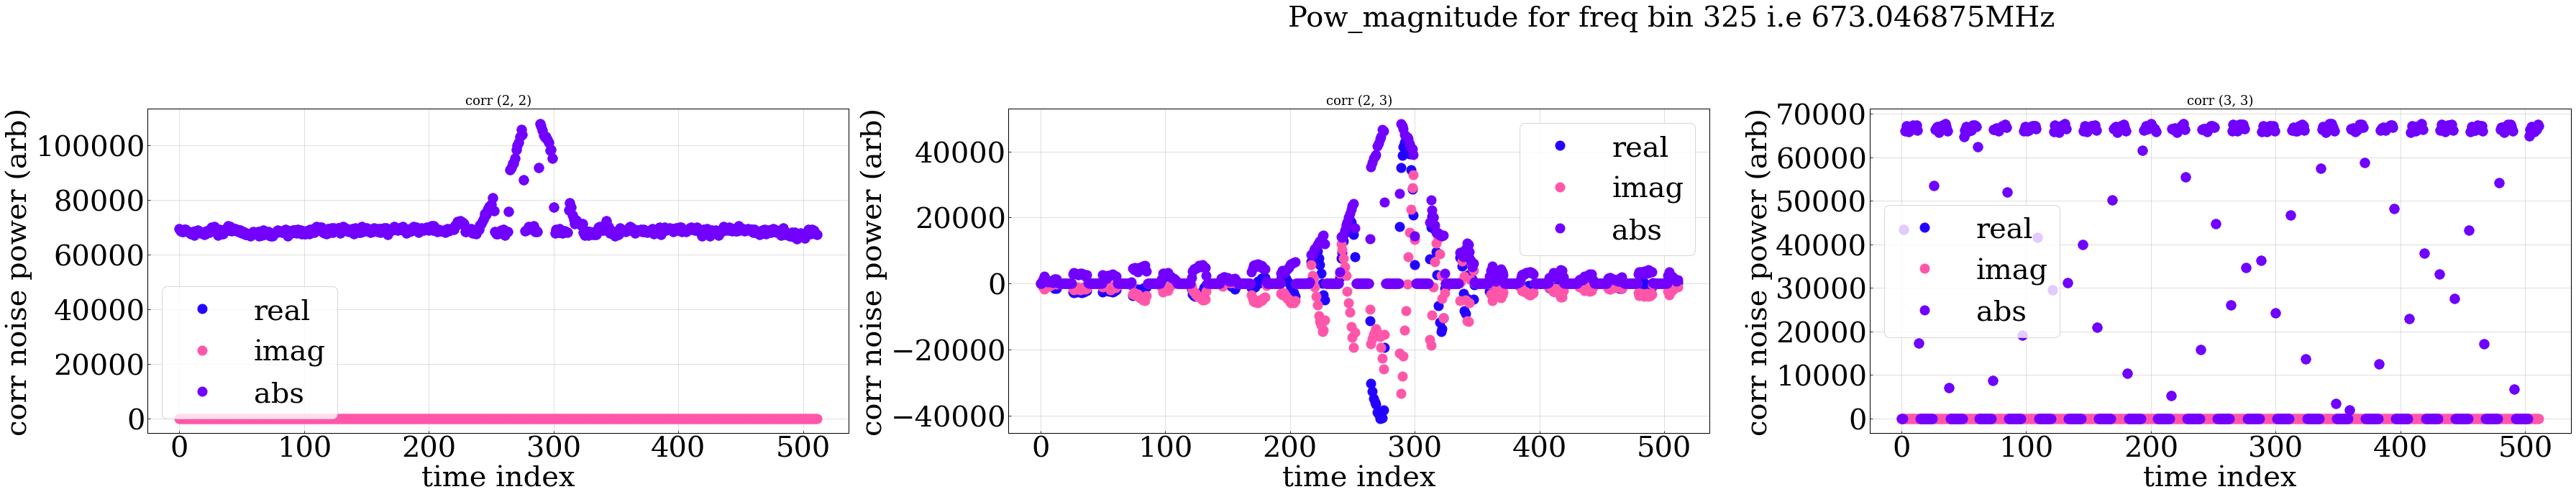

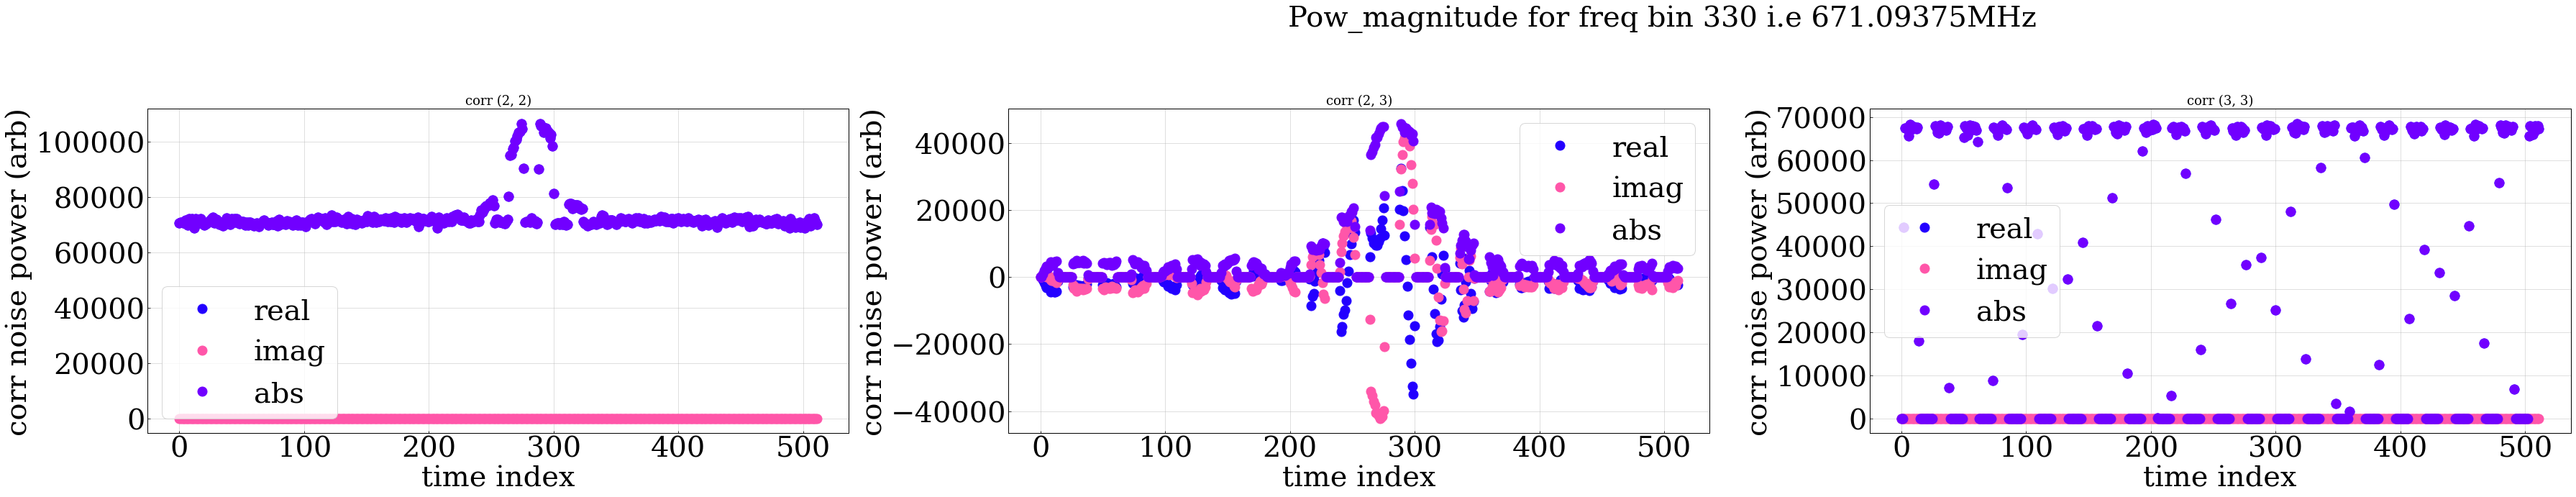

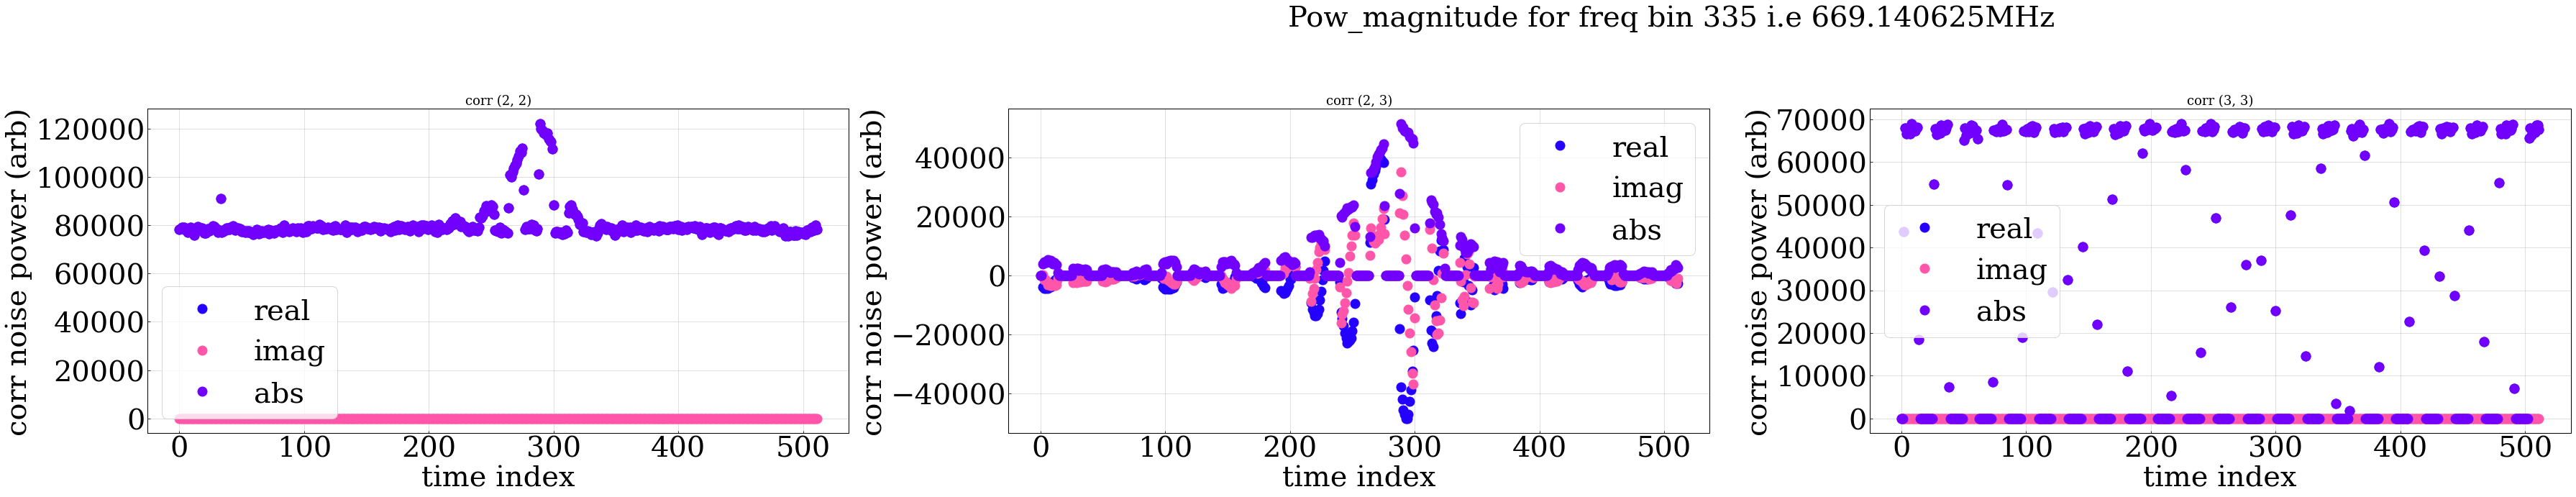

In [5]:

corr_data1_size=corr_data1.vis[:,:,:].shape 
print('corr noise data shape: {}'.format(corr_data1_size)) # time bins - freq bins - corr indices

## Plotting real and imag correlated system noise powers against time index for a given set of frequencies -- 

tmin,tmax=[0,corr_data1_size[0]]
freq_arr=[325,330,335]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        #ax.plot(corr_data1.vis.real[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[600], label='real')
        #ax.plot(corr_data1.vis.imag[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[1200], label='imag')
        #ax.plot(pow_mag1[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[800], label='abs')
        ax.plot(corr_data2.vis.real[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[600], label='real')
        ax.plot(corr_data2.vis.imag[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[1200], label='imag')
        ax.plot(pow_mag2[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[800], label='abs')
        ax.legend(fontsize=40)
        plt.xticks(fontsize=40)
        plt.yticks(fontsize=40)
        plt.title(f"corr {corr_data1.prod[corr_index]}")
        plt.xlabel("time index", fontsize=40)
        plt.ylabel("corr noise power (arb)", fontsize=40)
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left', fontsize=40)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65.pdf")

delta_time = np.diff(corr_data1.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data1.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data1.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [6]:
## Reading initial correlation files for correlated system noise -- 

file_path = '/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/*/*' 
corr_noise = read_corr_mode_h5(file_path, f_start=0, f_stop=2) 
corr_noise_mag, corr_noise_phase = get_mag_phase(corr_noise.vis)
print("done getting system correlated noise mag and phase")

corr_noise_size=corr_noise.vis[:,:,:].shape 
print('corr noise data shape: {}'.format(corr_noise_size)) # time bins - freq bins - corr indices

Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0000
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0000
Reading File: /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0001
Appended vis data and time stream from /Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z/0001
Done!!!!!!!
done getting system correlated noise mag and phase
corr noise data shape: (512, 1024, 10)


Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 512
lowest time bin 0 and highest time bin 512
21.47483648 seconds of data (considered for the plots)


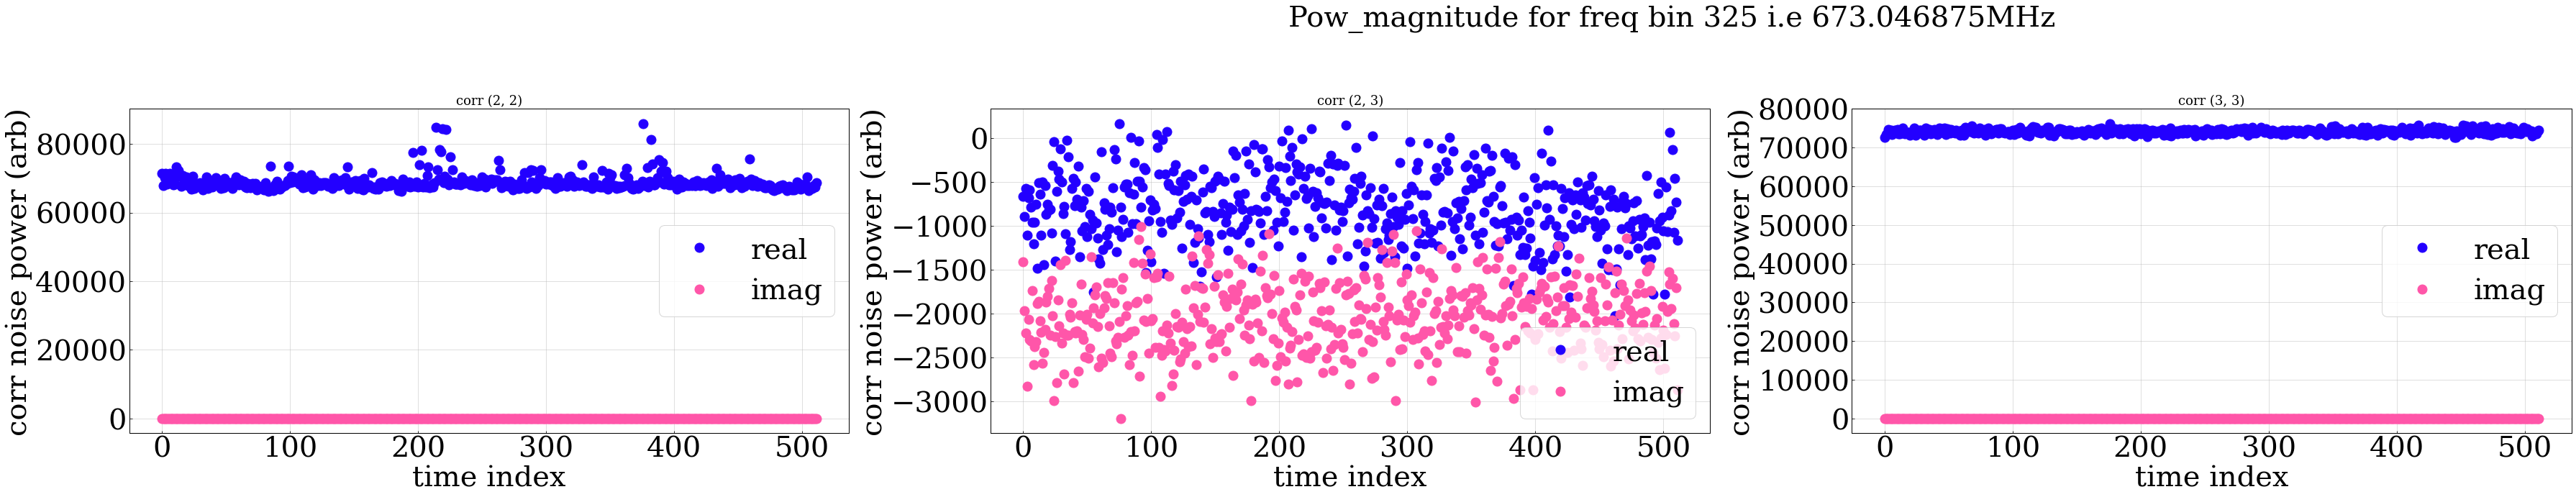

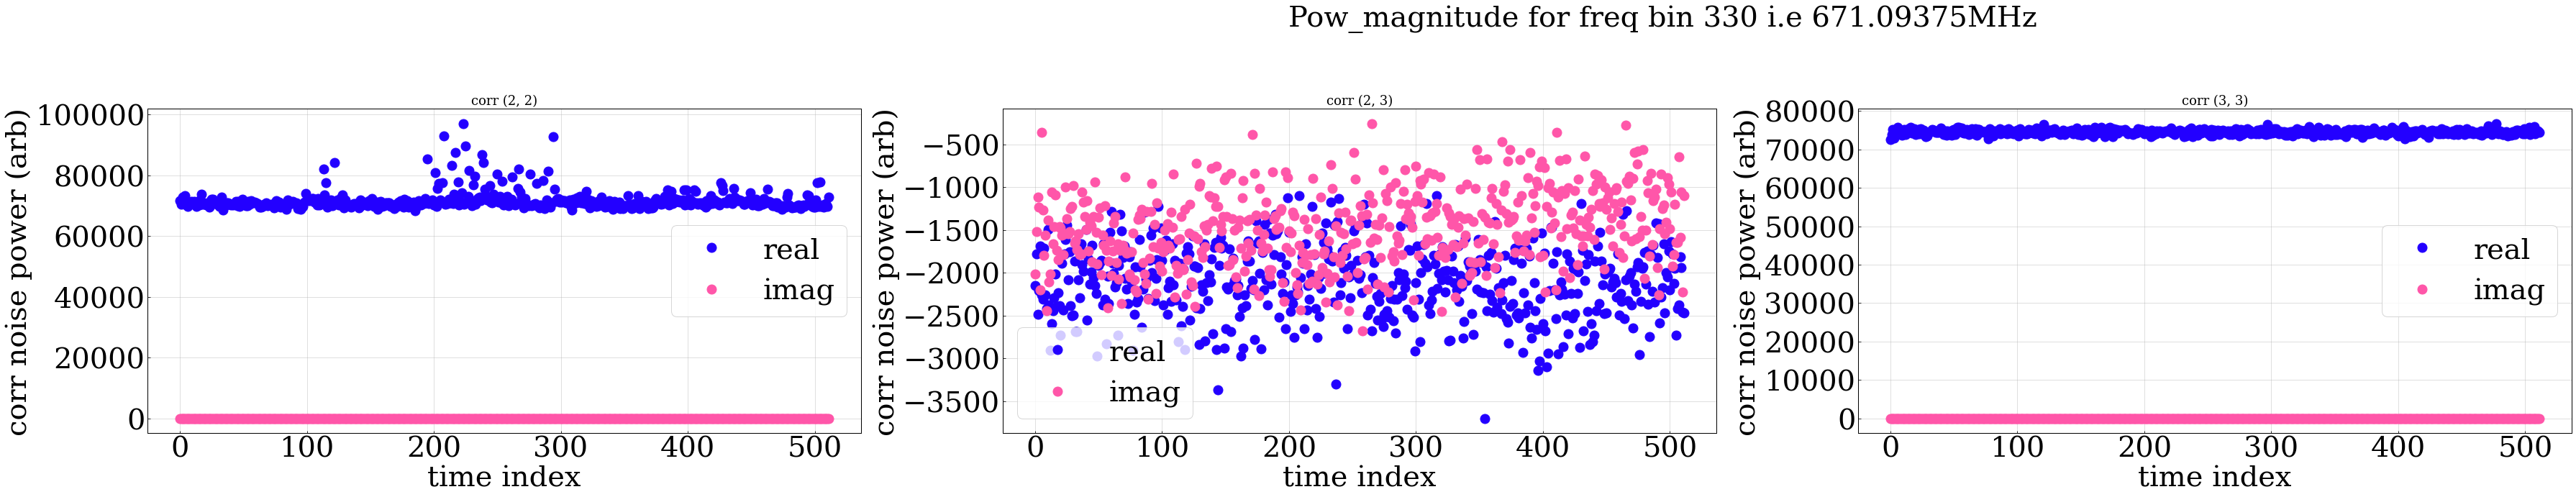

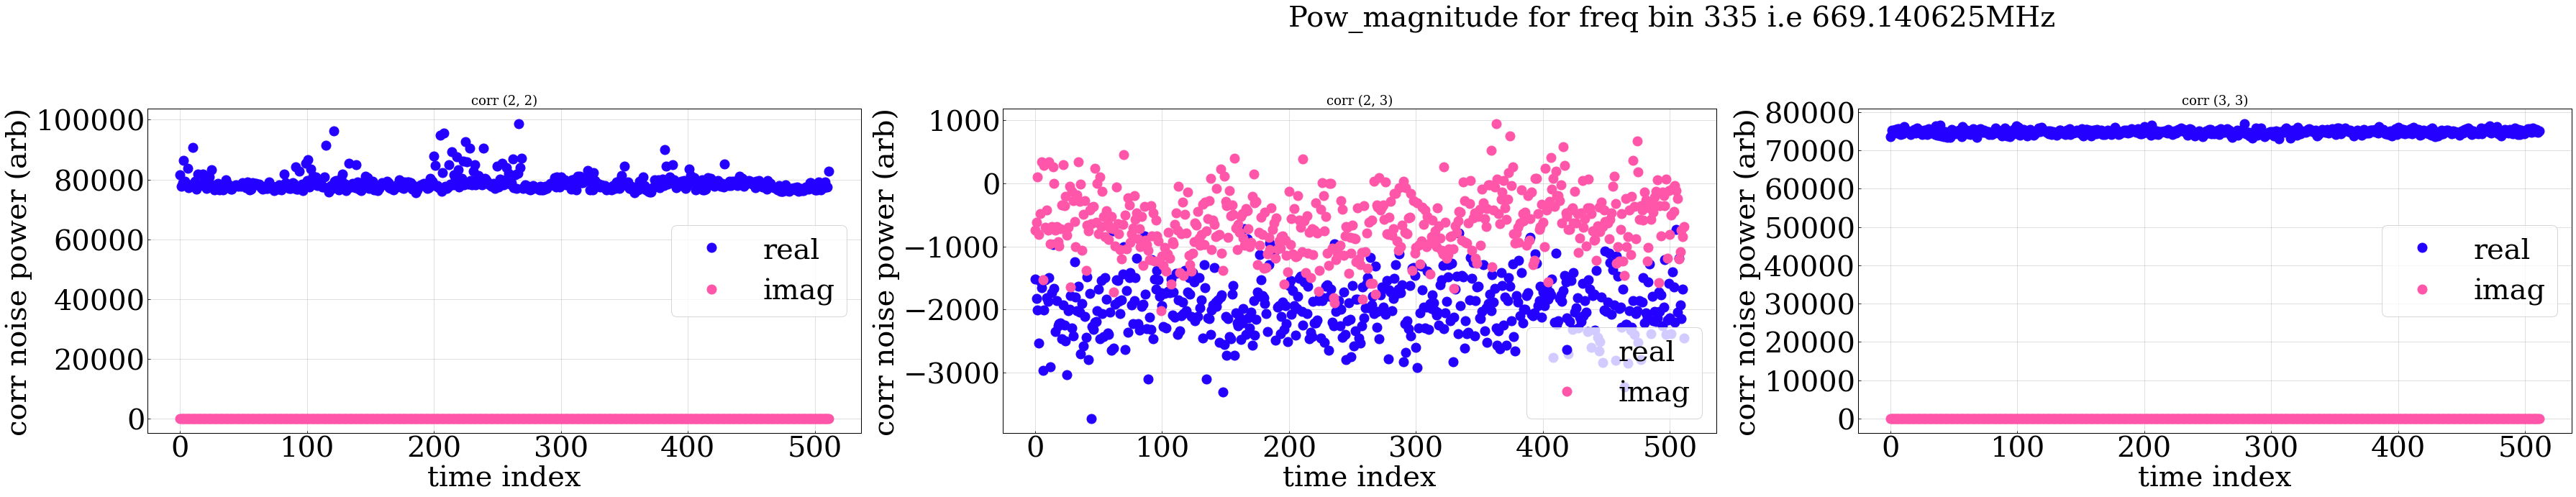

In [7]:
## Plotting real and imag correlated system noise powers against time index for a given set of frequencies -- 

tmin,tmax=[0,corr_noise_size[0]]
freq_arr=[325,330,335] # choose any frequency of interest 
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(corr_noise.vis.real[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[600], label='real')
        ax.plot(corr_noise.vis.imag[tmin:tmax,f_ind,corr_index],'o', markersize=13, c=colorsarr[1200], label='imag')
        ax.legend(fontsize=40)
        plt.xticks(fontsize=40)
        plt.yticks(fontsize=40)
        plt.title(f"corr {corr_noise.prod[corr_index]}")
        plt.xlabel("time index", fontsize=40)
        plt.ylabel("corr noise power (arb)", fontsize=40)
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left', fontsize=40)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65.pdf")

delta_time = np.diff(corr_noise.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_noise.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_noise.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

In [8]:
## Calculating median for first 512 indices for all frequencies (where test channel sees just system noise+sky)

med_I = np.zeros(1024, dtype=float)
med_Q = np.zeros(1024, dtype=float)

for i in range(1024):
    med_I[i]=np.median(corr_noise.vis.real[:,i,8])
    med_Q[i]=np.median(corr_noise.vis.imag[:,i,8])


Text(0, 0.5, 'corr noise power (arb)')

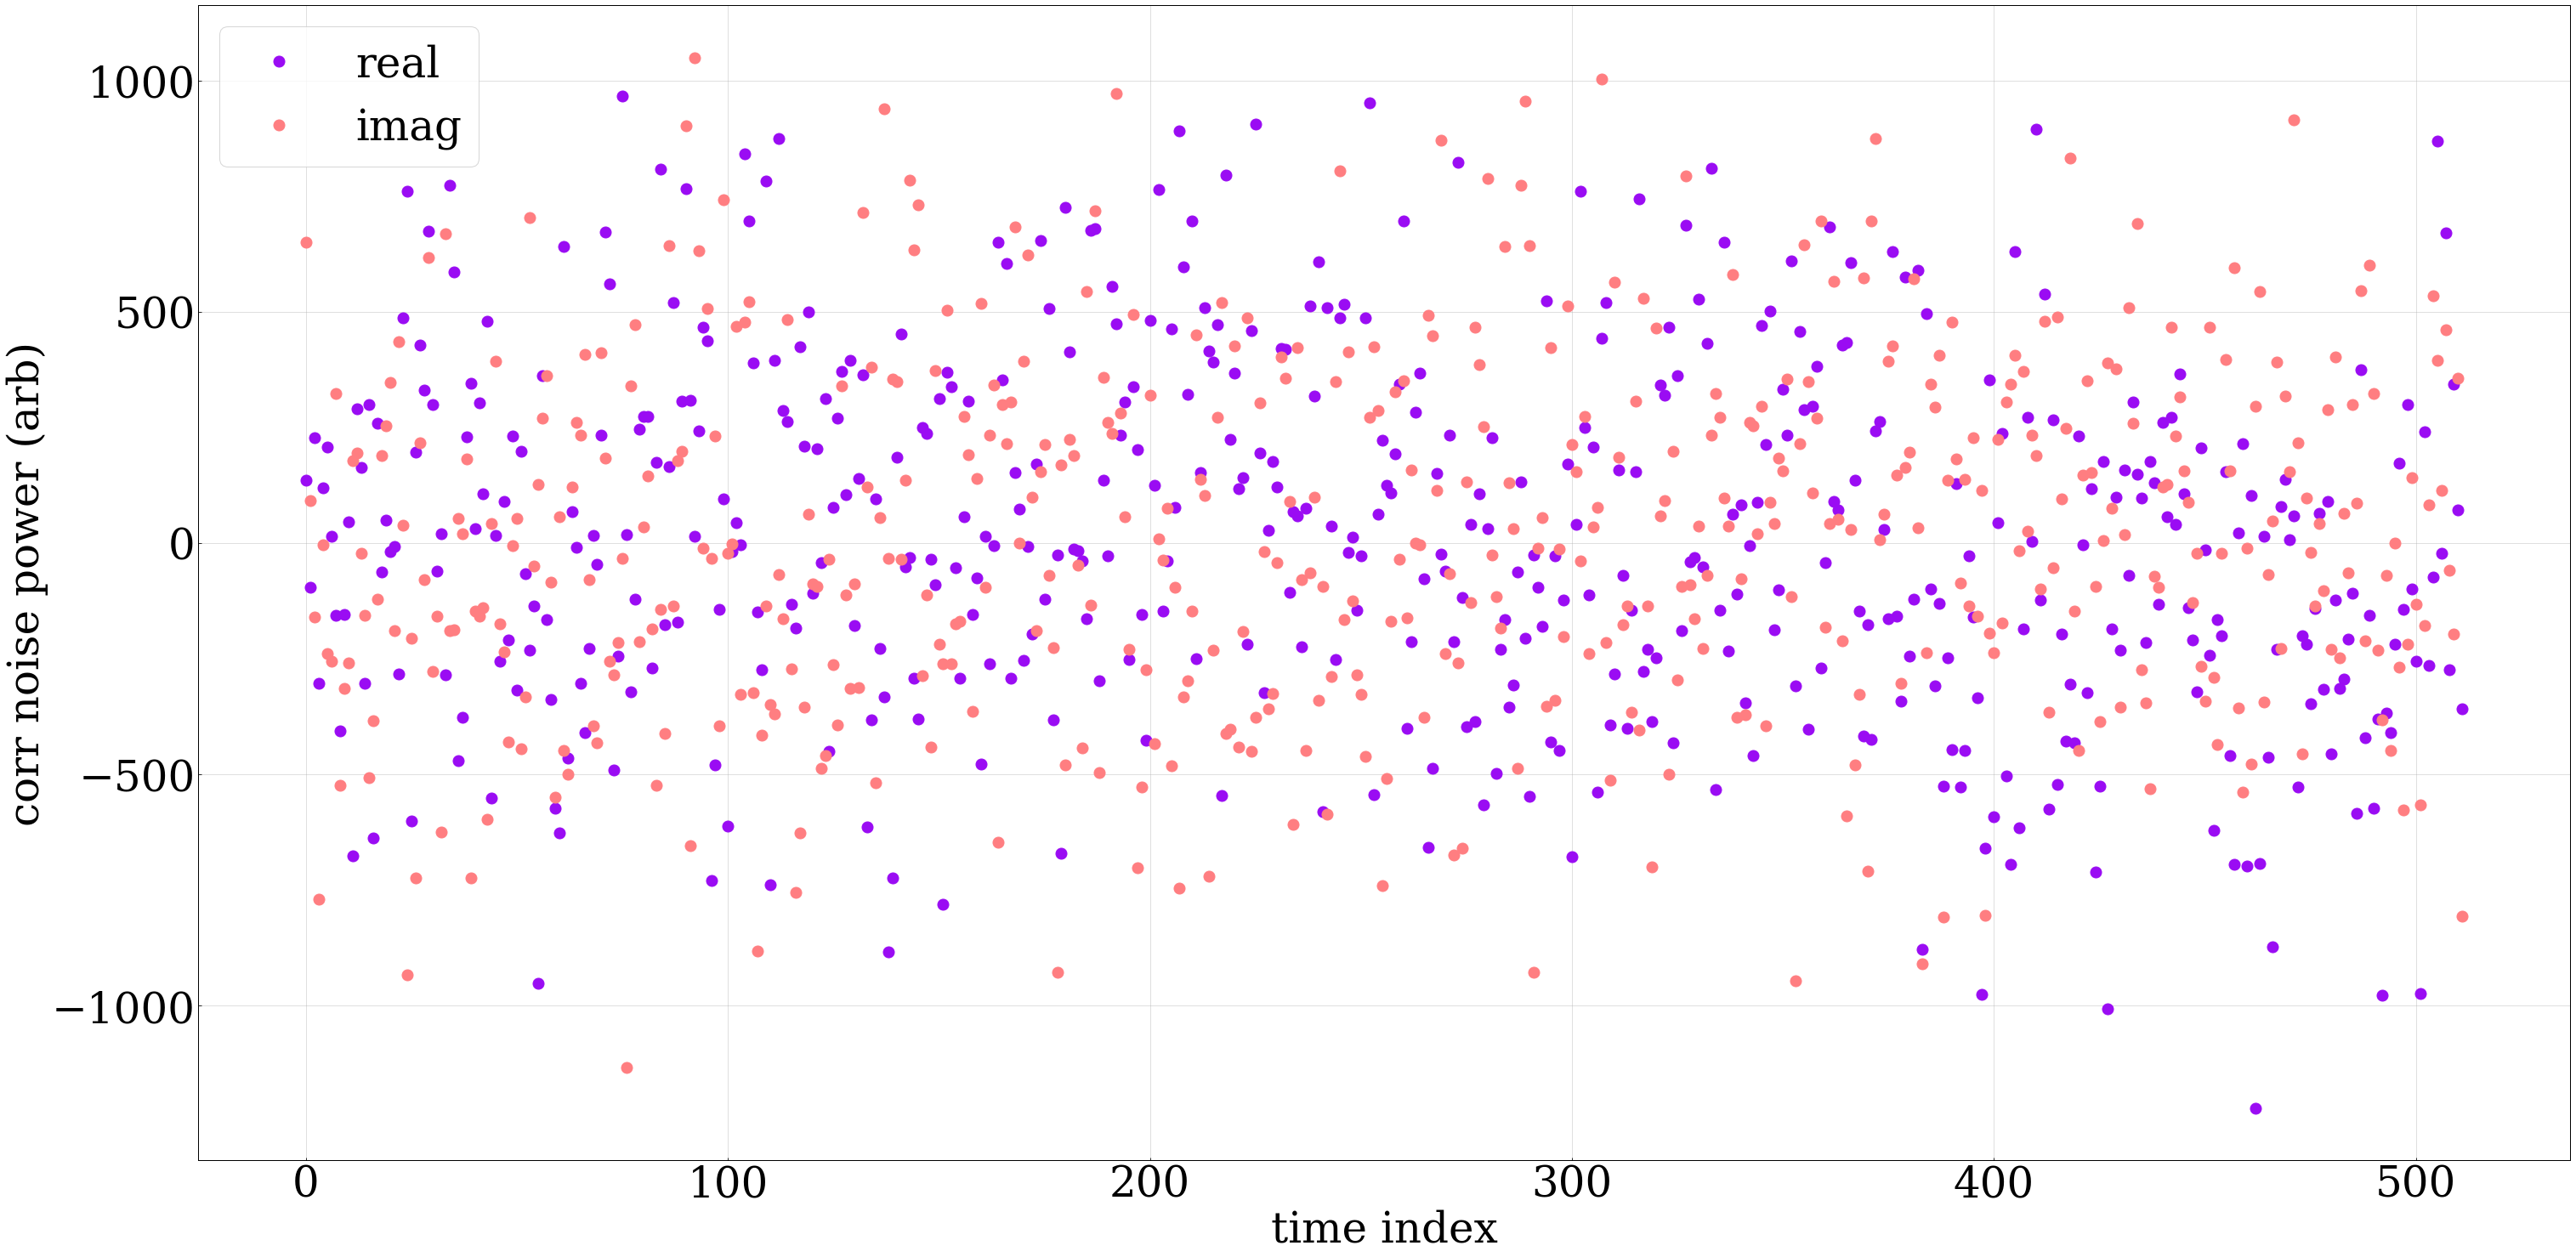

In [10]:
## getting the real and imag to zero at the start when there’s no signal-- 
## plotting the median subtracted noise --> 
colorz=cm_to_discrete(cm.gnuplot2, 10)

f_ind=325
corr_noise8_correctI=corr_noise.vis.real[:,f_ind,8]-med_I[f_ind]
corr_noise8_correctQ=corr_noise.vis.imag[:,f_ind,8]-med_Q[f_ind]

fig = plt.figure(figsize=[50,25])
ax=plt.subplot(111)
ax.plot(corr_noise8_correctI,'o', markersize=13, c=colorz(4), label='real')
ax.plot(corr_noise8_correctQ,'o', markersize=13, c=colorz(6), label='imag')
plt.xticks(fontsize=50)
plt.yticks(fontsize=50)
ax.legend(fontsize=50)
plt.xlabel("time index", fontsize=50)
plt.ylabel("corr noise power (arb)", fontsize=50)

## Morgan's code to sync the timestamps of drone data with correlator data and translate drone positions to beam angles --

In [11]:

def drone_angles_for_corr_range_simple(dish_location, drone_file, corr_data_directory,
                                       start_file=0, stop_file=-1,
                                       use_ctime=False, output='degrees',
                                       manual_drone_time_offset_s=0.0):
    """
    Compute drone angles relative to a single dish location for a specific correlator file time range.
    Interpolates the drone positions to the correlator timestamps.

    Time handling matches the concat script: all times converted to float seconds since epoch.

    NEW:
      manual_drone_time_offset_s: float (seconds)
          Added to drone timestamps (drone_times += offset) to manually shift alignment.
    """

    # -----------------------
    # Step 1: Load correlator timestamps
    # -----------------------
    all_files = sorted([f for f in os.listdir(corr_data_directory) if ".lock" not in f])
    filenames = all_files[start_file:stop_file]
    if len(filenames) == 0:
        raise ValueError("No correlator files found in the specified range.")

    t_list = []
    for fname in filenames:
        with h5py.File(os.path.join(corr_data_directory, fname), 'r') as fd:
            if use_ctime:
                t_file = fd['index_map']['time']['ctime'][:].astype(float)
            else:
                t_file = 1e-9 * fd['index_map']['time']['irigb_time'][:].astype(float)
            t_list.append(t_file)
    t_corr = np.concatenate(t_list)

    # Convert correlator times to seconds since epoch
    t_corr_sec = t_corr if use_ctime else t_corr  # already in seconds
    t_corr_sec = np.array(t_corr_sec, dtype=float)

    # -----------------------
    # Step 2: Load drone CSV timestamps
    # -----------------------
    df = pd.read_csv(drone_file, low_memory=False)

    if 'datetime(utc)' in df.columns and 'time(millisecond)' in df.columns:
        t0 = pd.to_datetime(df['datetime(utc)'], utc=True).iloc[0]
        drone_times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                                for x in df['time(millisecond)']])
    elif 'GPS:dateTimeStamp' in df.columns:
        drone_times = pd.to_datetime(df['GPS:dateTimeStamp'], utc=True).map(lambda t: t.timestamp()).values
    else:
        raise KeyError("No recognizable time columns in drone file.")

    # -----------------------
    # NEW: Apply manual time shift to drone timestamps (seconds)
    # -----------------------
    manual_drone_time_offset_s = float(manual_drone_time_offset_s)
    drone_times = drone_times + manual_drone_time_offset_s

    # -----------------------
    # Step 3: Mask drone data to correlator time range
    # -----------------------
    t_start_sec, t_stop_sec = t_corr_sec[0], t_corr_sec[-1]
    mask = (drone_times >= t_start_sec) & (drone_times <= t_stop_sec)
    if not mask.any():
        raise ValueError("No drone data falls within the correlator time range (after applying manual offset).")
    df_masked = df.loc[mask].copy()
    drone_times = drone_times[mask]

    # -----------------------
    # Step 4: Extract drone positions
    # -----------------------
    if 'RTKdata:Lat_P' in df_masked.columns:
        lat = df_masked['RTKdata:Lat_P'].values
        lon = df_masked['RTKdata:Lon_P'].values
        alt = df_masked['RTKdata:Hmsl_P'].values
    elif 'GPS(0):Lat' in df_masked.columns:
        lat = df_masked['GPS(0):Lat'].values
        lon = df_masked['GPS(0):Long'].values
        alt = df_masked['GPS(0):heightMSL'].values
    elif 'GPS:Lat' in df_masked.columns:
        lat = df_masked['GPS:Lat'].values
        lon = df_masked['GPS:Long'].values
        alt = df_masked['GPS:heightMSL'].values
    elif 'latitude' in df_masked.columns:
        lat = df_masked['latitude'].values
        lon = df_masked['longitude'].values
        if 'altitude(meters)' in df_masked.columns:
            alt = df_masked['altitude(meters)'].values
        elif 'altitude(feet)' in df_masked.columns:
            alt = df_masked['altitude(feet)'].values * 0.3048
        else:
            raise KeyError("No altitude column found in drone file.")
    else:
        raise KeyError("No recognizable latitude/longitude columns in drone file.")

    # Remove NaNs
    valid_mask = ~np.isnan(lat) & ~np.isnan(lon) & ~np.isnan(alt)
    lat, lon, alt = lat[valid_mask], lon[valid_mask], alt[valid_mask]
    drone_times = drone_times[valid_mask]

    # -----------------------
    # Step 5: Convert drone positions to local Cartesian coordinates
    # -----------------------
    origin_lat, origin_lon, origin_alt = dish_location
    prime_origin = pygeodesy.EcefCartesian(latlonh0=origin_lat, lon0=origin_lon, height0=origin_alt)

    drone_xyz = np.zeros((len(lat), 3))
    for i in range(len(lat)):
        p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
        drone_xyz[i] = prime_origin.forward(p).toVector()

    # -----------------------
    # Step 6: Compute angles relative to dish
    # -----------------------
    drone_xyz_rel = drone_xyz  # dish at origin

    # defining horizontal distance ignoring x
    horizontal_dist = np.abs(drone_xyz_rel[:, 1])
    vertical_dist = np.abs(drone_xyz_rel[:, 2])
    drone_angles = np.arctan2(horizontal_dist, vertical_dist)

    # -----------------------
    # Step 7: Interpolate angles to correlator timestamps
    # -----------------------
    angles_interp = np.interp(t_corr_sec, drone_times, drone_angles)

    if output.lower() == 'degrees':
        angles_interp = np.degrees(angles_interp)

    # -----------------------
    # Step 8: Print the max x-deviation (to get an idea of potential error)
    # -----------------------
    horizontal_x_dist = np.abs(drone_xyz_rel[:, 0])
    drone_angles_errors = np.arctan2(horizontal_x_dist, vertical_dist)

    horizontal_x_interp = np.interp(t_corr_sec, drone_times, horizontal_x_dist)
    angles_interp_errors = np.interp(t_corr_sec, drone_times, drone_angles_errors)

    if output.lower() == 'degrees':
        angles_interp_errors = np.degrees(angles_interp_errors)

    max_dev_deg = np.max(angles_interp_errors)
    avg_dev_deg = np.mean(angles_interp_errors)
    st_dev_deg  = np.std(angles_interp_errors)

    max_dev_m = np.max(horizontal_x_interp)
    avg_dev_m = np.mean(horizontal_x_interp)
    st_dev_m  = np.std(horizontal_x_interp)

    print(
        "Horizontal Deviation from Straight Path (x-direction):\n"
        "  Metric              |   Degrees   |   Meters\n"
        "  --------------------+-------------+-----------\n"
        f"  Max deviation       | {max_dev_deg:9.4f} | {max_dev_m:9.4f}\n"
        f"  Mean deviation      | {avg_dev_deg:9.4f} | {avg_dev_m:9.4f}\n"
        f"  Std. deviation      | {st_dev_deg:9.4f} | {st_dev_m:9.4f}"
    )

    return angles_interp

Horizontal Deviation from Straight Path (x-direction):
  Metric              |   Degrees   |   Meters
  --------------------+-------------+-----------
  Max deviation       |    1.5223 |    1.3268
  Mean deviation      |    0.7021 |    0.6129
  Std. deviation      |    0.2233 |    0.1948
Total drone positions recorded: 512
Horizontal Deviation from Straight Path (x-direction):
  Metric              |   Degrees   |   Meters
  --------------------+-------------+-----------
  Max deviation       |    1.0512 |    0.6620
  Mean deviation      |    0.6554 |    0.5234
  Std. deviation      |    0.1799 |    0.0942
Total drone positions recorded: 768


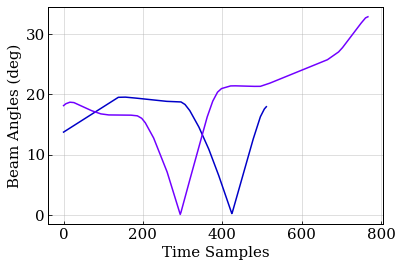

In [12]:
## for two beam passes 

drone_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_processed/YaleApr2025_drone_files/Apr-12th-2025-04-03PM-Flight-Airdata.csv"
corr_data_path = "/Users/kalyanibhopi94/Documents/research/Projects/digital_cal_source/data_raw/iceboard_data/corr_data/20250412T194037Z_WVUc52/corr/20250412T194134Z"
dish_loc = [41.31900474, -72.92132617, 25] # new dish centre -- given by Morgan 

# Compute angles using the simplified function
drone_angles1 = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=127,
    stop_file=129,
    use_ctime=True,
    output='degrees',
     manual_drone_time_offset_s=2.32
)

plt.plot(drone_angles1, c=colorsarr[400])
plt.xlabel("Time Samples")
plt.ylabel("Beam Angles (deg)")
print(f"Total drone positions recorded: {len(drone_angles1)}")

## KBB's addition -- NOTE THESE LINES 
# for just single pass and just one dip 
zero_idx = np.where(drone_angles1 == np.min(drone_angles1))[0][0]
drone_angles1[:zero_idx] = -drone_angles1[:zero_idx] 

## ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~` ## 

drone_angles2 = drone_angles_for_corr_range_simple(
    dish_location=dish_loc,
    drone_file=drone_data_path,
    corr_data_directory=corr_data_path,
    start_file=129,
    stop_file=132,
    use_ctime=True,
    output='degrees',
    manual_drone_time_offset_s=2.32
)


plt.plot(drone_angles2, c=colorsarr[800])
plt.xlabel("Time Samples")
plt.ylabel("Beam Angles (deg)")
print(f"Total drone positions recorded: {len(drone_angles2)}")

## KBB's addition -- NOTE THESE LINES 
# for just single pass and just one dip 
zero_idx = np.where(drone_angles2 == np.min(drone_angles2))[0][0]
drone_angles2[:zero_idx] = -drone_angles2[:zero_idx] 


## WTyndall's function imported for fitting ON and OFF pulse points 

In [14]:

"""
    WTyndall's function imported for fitting ON and OFF pulse points 
"""

def Extract_Source_Pulses_pub(self,f_ind):
    #If we don't have any variables, then we haven't loaded a yaml yet... and must run the function:
        pow_mag, pow_phase = get_mag_phase(self.vis)
        Period=0.9998e6
        Dutycycle=0.5e6
        t_bounds=[0,-1]
        minmaxpercents=[0.0001,100]
        #Create Switch Signal:
        self.pulse_period=Period
        self.pulse_dutycycle=Dutycycle
        delta_time = np.diff(self.time["irigb_time"])[1]*1e-9
        concat_duration=int(np.ceil(delta_time*len((self.vis)))) #actual full time in seconds
        time_s,time_dt,switch=tu.Pulsed_Data_Waveform(total_duration=concat_duration,period=self.pulse_period,duty_cycle_on=self.pulse_dutycycle)
        #Create t_offset range (1 period) and Pearson_r vars:
        t_offset_dist=np.arange(-1.0*self.pulse_period*1e-6,0.0,0.001)# 1ms steps 
        #n_channels = 10 # for GBO
        n_channels = 3 # for Yale 
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] # for Yale 
        Pr_arr=np.NaN*np.ones((n_channels,t_offset_dist.shape[0]))
        Pr_max_ind_per_channel=np.NaN*np.ones(n_channels) 
        Pr_max_t_0_per_channel=np.NaN*np.ones(n_channels)
        #Given parameters:
        num_bins = len(pow_mag[:,f_ind,9]) # 9 for yale; 9 in N2 matrix is ref channel
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_full = np.arange(num_bins) * time_bin_width

    
        ## Loop over channels to find/plot a time offset solution with some clever fitting:
        fig1,ax1=plt.subplots(nrows=1,ncols=1,figsize=(16,4))
        
        for i, ch_index in enumerate(channel_indices):
            ## Finding a baseline power level that’s almost the minimum, subtract it from the signal 
            ## so that ‘background’ power becomes zero before normalization.”
            minsubdata=self.vis[:,f_ind,ch_index]-np.percentile(self.vis[:,f_ind,ch_index],minmaxpercents[0])
            ## make all channels have the same range (0–1), so the Pearson correlation step later isn’t skewed by power differences.
            normminsubdata=minsubdata/np.percentile(minsubdata,minmaxpercents[1])
            ## clipping ensures baseline stays at 0 and maximum stays at 1 
            ## makes it directly comparable to our ideal square wave (0 = OFF, 1 = ON) 
            ## so Pearson correlation can find the best alignment.
            clipnormminsubdata=normminsubdata.clip(0,1)
            ## turns your cleaned signal into a function you can call at any time point,
            ## holding each sample’s value until the next one, so you can match it directly 
            ## to the ideal pulse pattern.
            stepped_func=interpolate.interp1d(t_full,clipnormminsubdata,kind='previous',fill_value='extrapolate')
            
            sniparr=np.where(time_s[np.where(time_s<=t_full[t_bounds[1]])[0]]>=t_full[t_bounds[0]])[0]
            t_restrict=np.intersect1d(np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],sniparr)

            ##Loop over all time offsets in t_offset_dist to find maximum correlation between squarewave and data:
            for j,t_offset in enumerate(t_offset_dist):
                shiftedswitch=np.interp(time_s,time_s+t_offset,switch)
                try:
                    Pr_arr[i,j]=pearsonr(stepped_func(time_s[t_restrict]).real,(shiftedswitch[t_restrict]))[0]
                except ValueError:
                    Pr_arr[i,j]=np.NAN
                    print(str(j)+" failed: " +str(t_offset))
            
            ax1.plot(t_offset_dist,Pr_arr[i,:],'*',label=str(i))
           
            try:
                maxPrind=np.where(Pr_arr[i,:]==np.nanmax(Pr_arr[i,:]))[0][0]
                
                ax1.plot(t_offset_dist[maxPrind],Pr_arr[i,maxPrind],'ro')

                
                Pr_max_ind_per_channel[i]=maxPrind
                Pr_max_t_0_per_channel[i]=t_offset_dist[maxPrind]
            except IndexError:
                Pr_max_ind_per_channel[i]=np.NAN
                Pr_max_t_0_per_channel[i]=np.NAN
                
        # Always considering reference channel for fitting (time offset from ref) as anyways switching is in sync 
        # Always point this index to the ref channel 
        #self.t_delta_pulse=Pr_max_t_0_per_channel[9]  # for GBO
        self.t_delta_pulse=Pr_max_t_0_per_channel[2]  # for Yale 
        ax1.axvline(self.t_delta_pulse,label="selected t_offset")
        ax1.legend(loc=1)
        plt.tight_layout()
        print("Maximum Pearson_R Correlations between data and square wave function:")
        print("  --> t_indices = {}".format(Pr_max_ind_per_channel))
        print("  --> t_deltas = {}".format(np.around(Pr_max_t_0_per_channel,decimals=3)))
        print("Selecting square wave function time offset:")
        print("  --> t_delta_pulse = {:.10f}".format(self.t_delta_pulse))

        
        
        t_arr_datetime = t_full 
        #Interpolate the switching function with the concat timestamps using either input or found t_delta_pulse:
        num_bins = len(pow_mag[:,f_ind,1])
        time_bin_width = np.diff(self.time["irigb_time"])[1]*1e-9 # seconds
        #Create the array of time values:
        t_for_interp_out=np.arange(num_bins) * time_bin_width #defining same as t_full
        t_for_interp_in=np.array([m.total_seconds() for m in time_dt])
        switch_interp_f=np.interp(t_for_interp_out,t_for_interp_in+self.t_delta_pulse,switch)
        self.switch_signal=switch
        self.switch_time=t_for_interp_in
        self.switch_signal_interp=switch_interp_f
        #print(switch_interp_f)
        
        #Once we have our time offset, we must extract indices where the source is on/off/rising:
        self.inds_span=np.union1d(list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),\
                                  np.intersect1d(np.where(1>switch_interp_f),np.where(switch_interp_f>0))).tolist()
        self.inds_on=list(set(np.where(switch_interp_f==1)[0])-set(self.inds_span))
        self.inds_off=list(set(np.where(switch_interp_f==0)[0])-set(self.inds_span))
 
        ## Each of these lists of indices should also have no overlap. Let's print to see:
        print("Finding relevant pulsing indices and checking for overlaps:")
        print("  --> on/off ind intersection:",np.intersect1d(self.inds_on,self.inds_off))
        print("  --> on/span ind intersection:",np.intersect1d(self.inds_on,self.inds_span))
        print("  --> off/span ind intersection:",np.intersect1d(self.inds_off,self.inds_span))

        #Making subsets of on and off indices for individual ON/OFFs: 
        indon_list=list(chunk_lists_(self.inds_on))
        indoff_list=list(chunk_lists_(self.inds_off))
        #Calculating stats for individual ON/OFF pulses:
        #channel_indices = [0,1,2,3,4,5,6,7,8,9] # for GBO
        channel_indices = [7,8,9] #for Yale 
        
        fig3=plt.figure(figsize=(16,int(4*n_channels/2)))
        for i,channel_index in enumerate(channel_indices):
            print("Frequency bin: "+str(f_ind))
            freq=400+((1024-f_ind)*0.390625)
            print(f"Frequency: {freq} MHz")
            all_data = pow_mag[:,f_ind,channel_index]
            
            ax=fig3.add_subplot(n_channels,1,i+1)
            ax.plot(t_arr_datetime[:],pow_mag[:,f_ind,channel_index],label='data')
            ax.scatter(t_arr_datetime[self.inds_on],all_data[self.inds_on],label='on',color='red',s=10)
            ax.scatter(t_arr_datetime[self.inds_off],all_data[self.inds_off],label='off',color='green',s=10)
            ax.scatter(t_arr_datetime[self.inds_span],all_data[self.inds_span],label='span',color='blue',s=10)
            ax.set_ylabel("Log Power Received [$ADU^2$]")
            ax.set_xlabel("Datetime")
            ax.legend(loc=3)
            #ax.set_xlim(t_arr_datetime[t_bounds[0]],t_arr_datetime[t_bounds[1]])
            
        # Visualize alignment of switch_interp_f with actual data
        fig_align, ax_align = plt.subplots(figsize=(12, 6))
        #corr33_dat= pow_mag[:,f_ind,3] # for GBO
        corr99_dat= pow_mag[:,f_ind,9] # for Yale 
        #ax_align.plot(t_arr_datetime, corr33_dat, label='Actual Data') # for GBO
        ax_align.plot(t_arr_datetime, corr99_dat, label='Actual Data')
        ax_align.set_xlabel('Datetime')
        ax_align.set_ylabel('Data / Interpolated Switch')
        ax_align.set_title('Alignment of Interpolated Switch with Actual Data')
        ax_align.legend()
        plt.tight_layout()
        plt.show()
        
        #fig3.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/publication_figures/1d_transit_{freq}MHZ.pdf', 
        #    dpi=300) 
        
        return self.inds_on, self.inds_off, self.inds_span

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [574. 328. 576.]
  --> t_deltas = [-0.426 -0.672 -0.424]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.4238000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []
Frequency bin: 325
Frequency: 673.046875 MHz
Frequency bin: 325
Frequency: 673.046875 MHz
Frequency bin: 325
Frequency: 673.046875 MHz


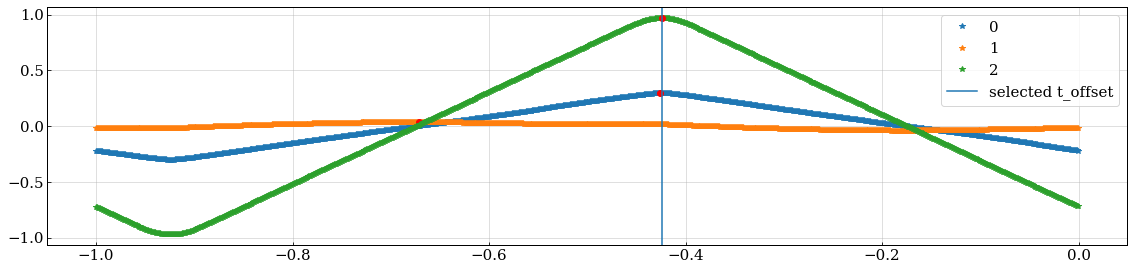

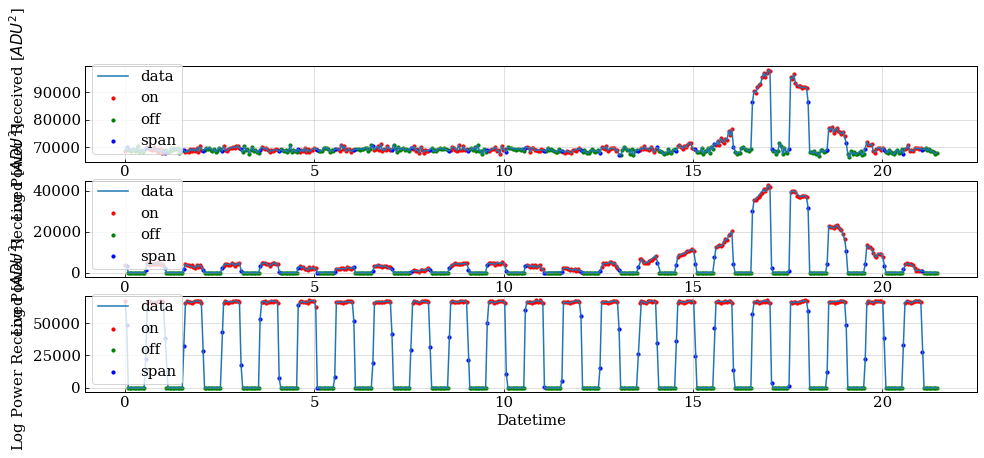

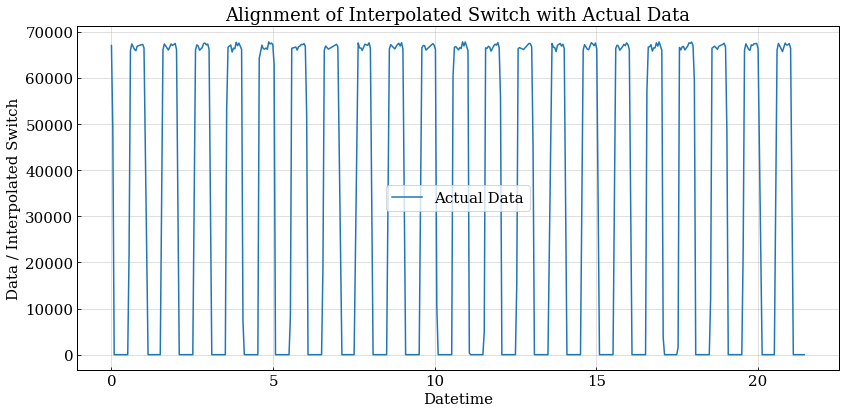

Maximum Pearson_R Correlations between data and square wave function:
  --> t_indices = [ 89. 840. 101.]
  --> t_deltas = [-0.911 -0.16  -0.899]
Selecting square wave function time offset:
  --> t_delta_pulse = -0.8988000000
Finding relevant pulsing indices and checking for overlaps:
  --> on/off ind intersection: []
  --> on/span ind intersection: []
  --> off/span ind intersection: []
Frequency bin: 325
Frequency: 673.046875 MHz
Frequency bin: 325
Frequency: 673.046875 MHz
Frequency bin: 325
Frequency: 673.046875 MHz


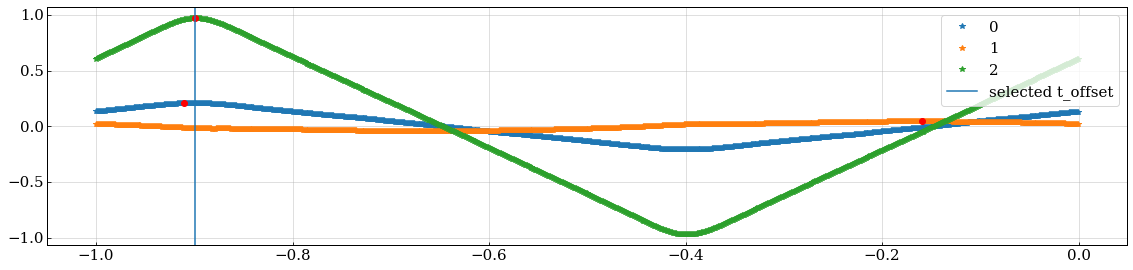

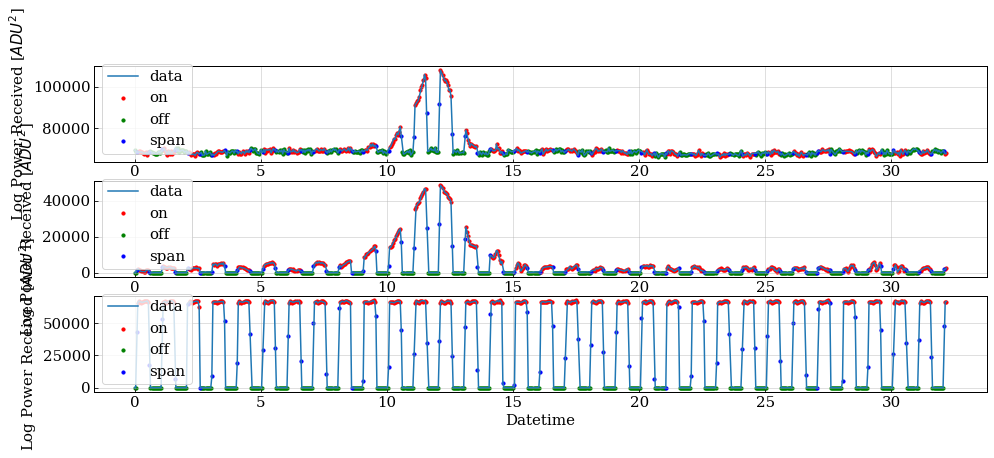

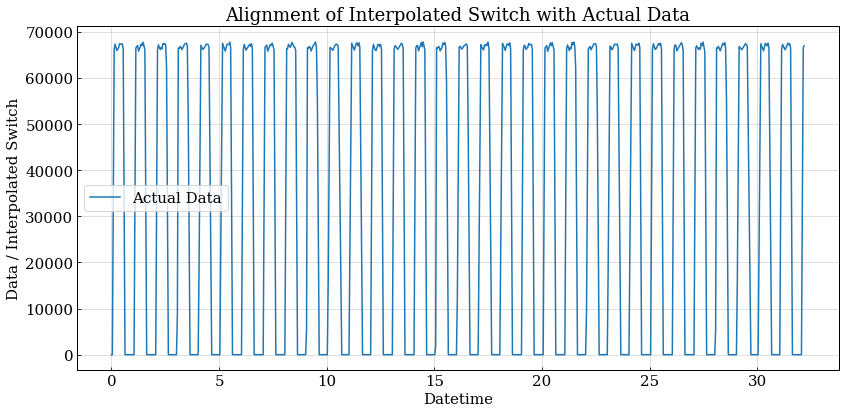

In [15]:
## for multiple beam passes or flights -- change accordingly 

inds_on1, inds_off1, inds_span1=Extract_Source_Pulses_pub(corr_data1, f_ind=325)
inds_on2, inds_off2, inds_span2=Extract_Source_Pulses_pub(corr_data2, f_ind=325)
#inds_on3, inds_off3, inds_span3=Extract_Source_Pulses_pub(corr_data3, f_ind=325) 

In [16]:

## -----------------------------------------------------------------------------------------
## MAke sure you run this cell "ONLY ONCE" because its modifying original data arrays 
## if hit multiple times, start from the code cell again which reads corr data files 
## -----------------------------------------------------------------------------------------

## correction applied -- getting rid of constant phase offset (subtracting system noise)

f_ind=325 # though already defined above while computing correlated noise median
corr_ind=8
# 1m/s flight--
for i, ind in enumerate(inds_on1):
    corr_data1.vis.real[ind,f_ind, corr_ind] -= med_I[f_ind]
    corr_data1.vis.imag[ind,f_ind, corr_ind] -= med_Q[f_ind]
    
# 2.5m/s flight second pass  -- 
for i, ind in enumerate(inds_on2):
    corr_data2.vis.real[ind,f_ind, corr_ind] -= med_I[f_ind]
    corr_data2.vis.imag[ind,f_ind, corr_ind] -= med_Q[f_ind]

# 2.5m/s flight first pass  -- 
#for i, ind in enumerate(inds_on3):
#    corr_data3.vis.real[ind,f_ind, corr_ind] -= med_I[f_ind]
#    corr_data3.vis.imag[ind,f_ind, corr_ind] -= med_Q[f_ind]
    
pow_mag1[:,f_ind,corr_ind]=np.abs(corr_data1.vis[:,f_ind,corr_ind])
pow_mag2[:,f_ind,corr_ind]=np.abs(corr_data2.vis[:,f_ind,corr_ind])
#pow_mag3[:,f_ind,corr_ind]=np.abs(corr_data3.vis[:,f_ind,corr_ind])

Each time bin is: 0.04194304 seconds
total time bins (considered for the plots) are 512
lowest time bin 0 and highest time bin 512
21.47483648 seconds of data (considered for the plots)


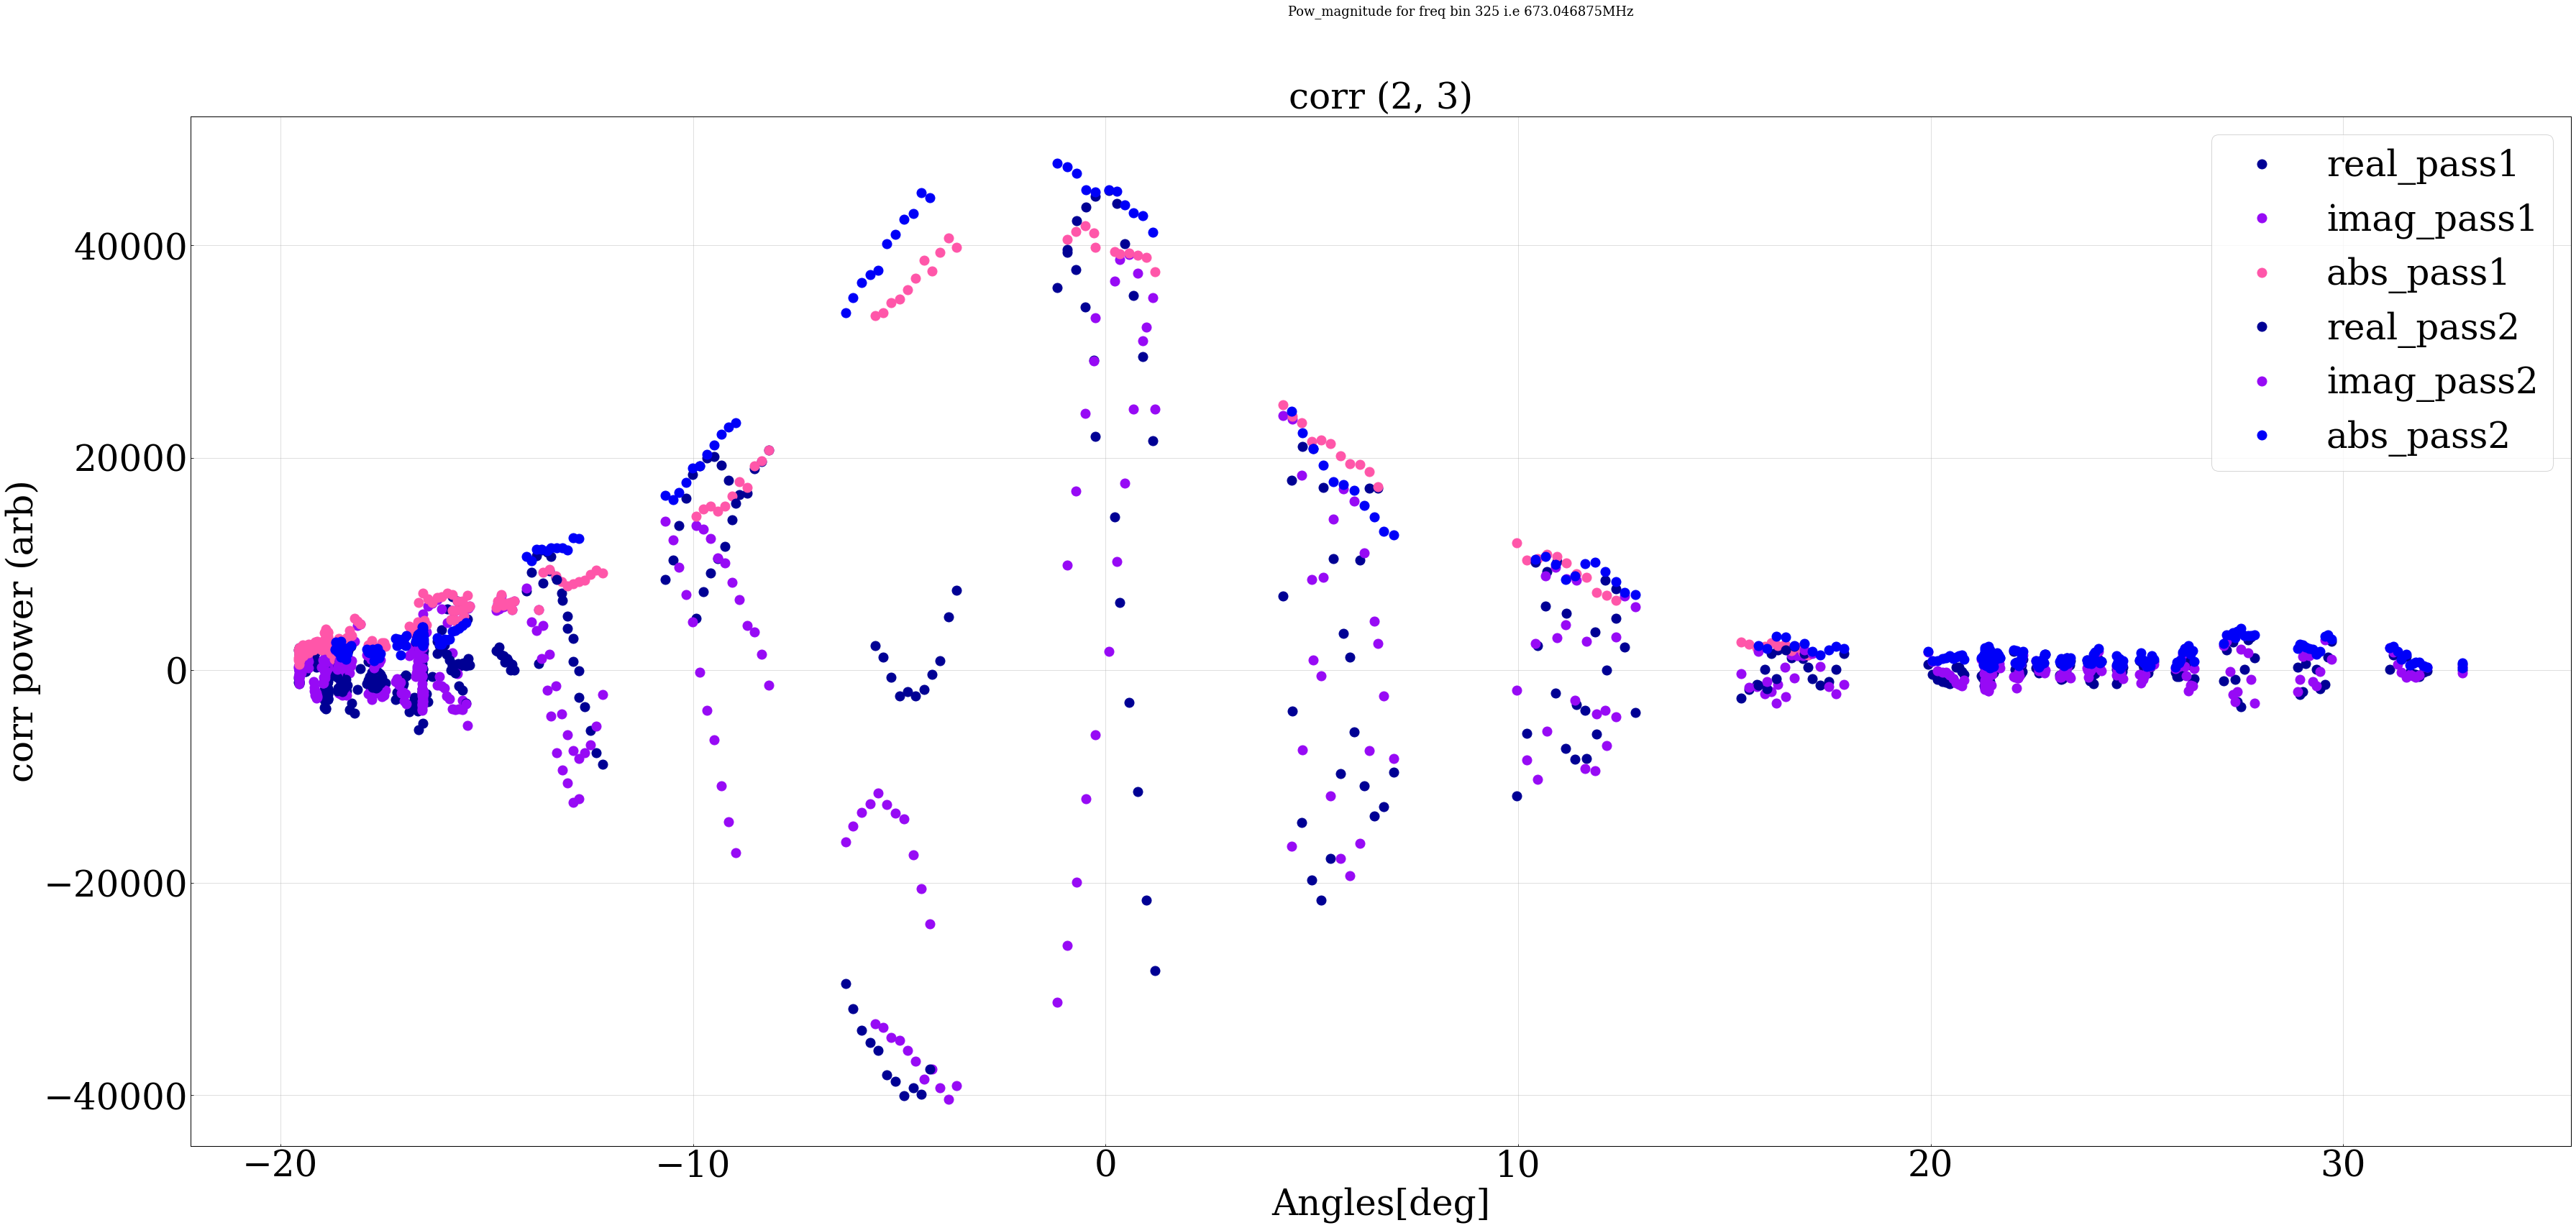

In [17]:
#Plotting real and imag correlation powers against drone angles for a given set of frequencies -- 
# 1m/s flight --
corr_size1=corr_data1.vis[:,:,:].shape 
tmin,tmax=[0,corr_size1[0]]
delta_time = np.diff(corr_data1.time["irigb_time"])[1] * 1e-9
xtime = np.linspace(0, delta_time * tmax, tmax)

freq_arr=[f_ind]
corr_indices=[8]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[50,25])
    freq=400+((1024-f_ind)*0.390625)
    for index, corr_index in enumerate(corr_indices): 
        ax=plt.subplot(dim2, dim1, index+1)
        ax.plot(drone_angles1[inds_on1],corr_data1.vis.real[inds_on1,f_ind,corr_index],'o', markersize=13, c=colorsarr[300], label='real_pass1')
        ax.plot(drone_angles1[inds_on1],corr_data1.vis.imag[inds_on1,f_ind,corr_index],'o', markersize=13, c=colorsarr[900], label='imag_pass1')
        ax.plot(drone_angles1[inds_on1],pow_mag1[inds_on1,f_ind,corr_index],'o', markersize=13, c=colorsarr[1200], label='abs_pass1')
        ax.plot(drone_angles2[inds_on2],corr_data2.vis.real[inds_on2,f_ind,corr_index],'o', markersize=13, c=colorsarr[300], label='real_pass2')
        ax.plot(drone_angles2[inds_on2],corr_data2.vis.imag[inds_on2,f_ind,corr_index],'o', markersize=13, c=colorsarr[900], label='imag_pass2')
        ax.plot(drone_angles2[inds_on2],pow_mag2[inds_on2,f_ind,corr_index],'o', markersize=13, c=colorsarr[500], label='abs_pass2')
        ax.legend(fontsize=50)
        ax.set_title(f"corr {corr_data1.prod[corr_index]}", fontsize=50)
        ax.set_xlabel("Angles[deg]", fontsize=50)
        ax.tick_params(axis='both', which='major', labelsize=50)
        ax.set_ylabel("corr power (arb)", fontsize=50)
        plt.suptitle(f"Pow_magnitude for freq bin {f_ind} i.e {freq}MHz", ha='left')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    #plt.savefig("/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/phase_offset_investigate/real_imag_corr_powers_1ms_files61-65_DC_IQ_corrected_med.pdf")

delta_time = np.diff(corr_data1.time["irigb_time"])[1]*1e-9 
print(f"Each time bin is: {delta_time} seconds")
print(f"total time bins (considered for the plots) are {len(corr_data1.vis[tmin:tmax,0,0])}") 
print(f"lowest time bin {tmin} and highest time bin {tmax}")
print(f"{delta_time*len(corr_data1.vis[tmin:tmax,0,0])} seconds of data (considered for the plots)") 

## overlaying autos and crosses from drone beam pass -- 

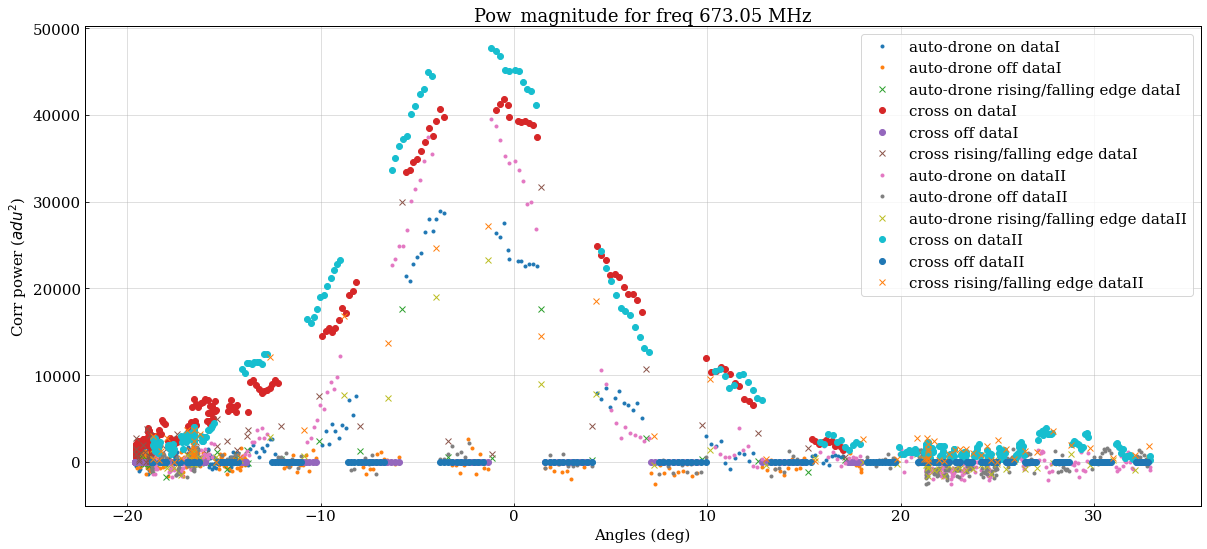

In [18]:
## for two beam passes/flights -- 

freq_arr=[325]
corr_indices=[7,8,9]
dim1 = math.floor(math.sqrt(len(corr_indices)*len(freq_arr)))
dim2 = math.ceil(len(corr_indices)*len(freq_arr)/dim1)
for index,f_ind in enumerate(freq_arr):
    colorsarr=cm.gnuplot2(np.linspace(0,1,2048))
    fig = plt.figure(figsize=[20,30])
    freq=400+((1024-f_ind)*0.390625)
    ax=plt.subplot(dim2, dim1, index+1)
    
    ax.plot(drone_angles1[inds_on1],pow_mag1[inds_on1,f_ind,7]-np.median(pow_mag1[inds_off1,f_ind,7]),'.', label='auto-drone on dataI')
    ax.plot(drone_angles1[inds_off1],pow_mag1[inds_off1,f_ind,7]-np.median(pow_mag1[inds_off1,f_ind,7]),'.', label='auto-drone off dataI')
    ax.plot(drone_angles1[inds_span1],pow_mag1[inds_span1,f_ind,7]-np.median(pow_mag1[inds_off1,f_ind,7]),'x', label='auto-drone rising/falling edge dataI')
    
    ax.plot(drone_angles1[inds_on1],pow_mag1[inds_on1,f_ind,8],'o', label='cross on dataI')
    ax.plot(drone_angles1[inds_off1],pow_mag1[inds_off1,f_ind,8],'o', label='cross off dataI')
    ax.plot(drone_angles1[inds_span1],pow_mag1[inds_span1,f_ind,8],'x', label='cross rising/falling edge dataI')
    
    #ax.plot(drone_angles1[inds_on1],pow_mag1[inds_on1,f_ind,9],'.', label='auto-ref on dataI')
    #ax.plot(drone_angles1[inds_off1],pow_mag1[inds_off1,f_ind,9],'.', label='auto-ref off dataI')
    #ax.plot(drone_angles1[inds_span1],pow_mag1[inds_span1,f_ind,9],'x', label='auto-ref rising/falling edge dataI')
    
    ax.plot(drone_angles2[inds_on2],pow_mag2[inds_on2,f_ind,7]-np.median(pow_mag2[inds_off2,f_ind,7]),'.', label='auto-drone on dataII')
    ax.plot(drone_angles2[inds_off2],pow_mag2[inds_off2,f_ind,7]-np.median(pow_mag2[inds_off2,f_ind,7]),'.', label='auto-drone off dataII')
    ax.plot(drone_angles2[inds_span2],pow_mag2[inds_span2,f_ind,7]-np.median(pow_mag2[inds_off2,f_ind,7]),'x', label='auto-drone rising/falling edge dataII')
    
    ax.plot(drone_angles2[inds_on2], pow_mag2[inds_on2,f_ind,8],'o', label='cross on dataII')
    ax.plot(drone_angles2[inds_off2],pow_mag2[inds_off2,f_ind,8],'o', label='cross off dataII')
    ax.plot(drone_angles2[inds_span2],pow_mag2[inds_span2,f_ind,8],'x', label='cross rising/falling edge dataII')
    
    #ax.plot(-drone_angles2[inds_on2],pow_mag2[inds_on2,f_ind,9],'.', label='auto-ref on dataII')
    #ax.plot(-drone_angles2[inds_off2],pow_mag2[inds_off2,f_ind,9],'.', label='auto-ref off dataII')
    #ax.plot(-drone_angles2[inds_span2],pow_mag2[inds_span2,f_ind,9],'x', label='auto-ref rising/falling edge dataII')
    
    #ax.set_ylim(-6000,130000)
    plt.title(f"Pow_magnitude for freq {freq:.2f} MHz")
    plt.xlabel("Angles (deg)")
    plt.ylabel("Corr power ($adu^2$)")
    plt.legend(loc='upper right') # ncol=2
    
#fig.savefig(f'/Users/kalyanibhopi94/Documents/kalyanib_dns/corr_dns_plots/drone_testing_4x2_Apr2025/Apr12...037Z/publication_figures/PowMagCross_2flight_passes_{freq}.pdf', 
#            dpi=300)